In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

This notebook is based on the code provided by Scikit-learn developers

https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

### Classifier comparison

This notebook allows you to compare the predictions by different kinds of classifiers. The cell below contains a list of different classifiers, some of which are commented. You can uncomment or add your own to plot and compare models.

In [3]:
classifiers = [
    ("Logistic Regression", LogisticRegression()),
    # ("Linear SVM", SVC(kernel="linear", C=0.025, random_state=42)),
    ("Nearest Neighbors", KNeighborsClassifier(3)),
    # ("RBF SVM", SVC(gamma=2, C=1, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=5, random_state=42)),
    # ("Random Forest", RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1, random_state=42)),
    # ("AdaBoost", AdaBoostClassifier(random_state=42)),
    ("Neural Net", MLPClassifier(alpha=1, max_iter=1000, random_state=42)),
    # ("Naive Bayes", GaussianNB()),
    # ("QDA", QuadraticDiscriminantAnalysis()),
    # ("Gaussian Process", GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42)),
]

In [4]:
names, classifiers = list(map(lambda x: x[0], classifiers)), list(map(lambda x: x[1], classifiers))

In the cell below, we create a linearly separable dataset, meaning that a classifier with a linear decision boundary should be suffucient to accurately predict class labels.

In [5]:
X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

We create a list of datasets below, which will be used to create the plots. Each dataset in the cell below will have a corresponding row in the plot.

In addition to the linearly separable dataset, we create a 'Two Moons' dataset which is more complex and not linearly separable. There is also a third which creates points in two circles.

In [6]:
datasets = [
    linearly_separable,
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
]

Below we plot the results of training different types of classifiers. Each row corresponds to a dataset and each column is a classifier / model.

The colored regions indicate the class label predicitions by each model. Notice how the regions are shaded. Unlike the plots in the KNN notebook where we only colored the regions based on the predicted label (and got a clear decision boundary), we shade the regions here based on how uncertain the model is about its prediction. So lighter regions correspond to more uncertainty about the prediction, whereas say a dark red region means the model is very sure about the point being `red`.

Different models yield different patterns. Logistic regression, which is linear, yields a linear decision boundary and is not good at classifying the nonlinear Moons and Circles datasets, while other models do a better job. The performance can be compared using the accuracy which is displayed in the bottom right corner of each subplot.

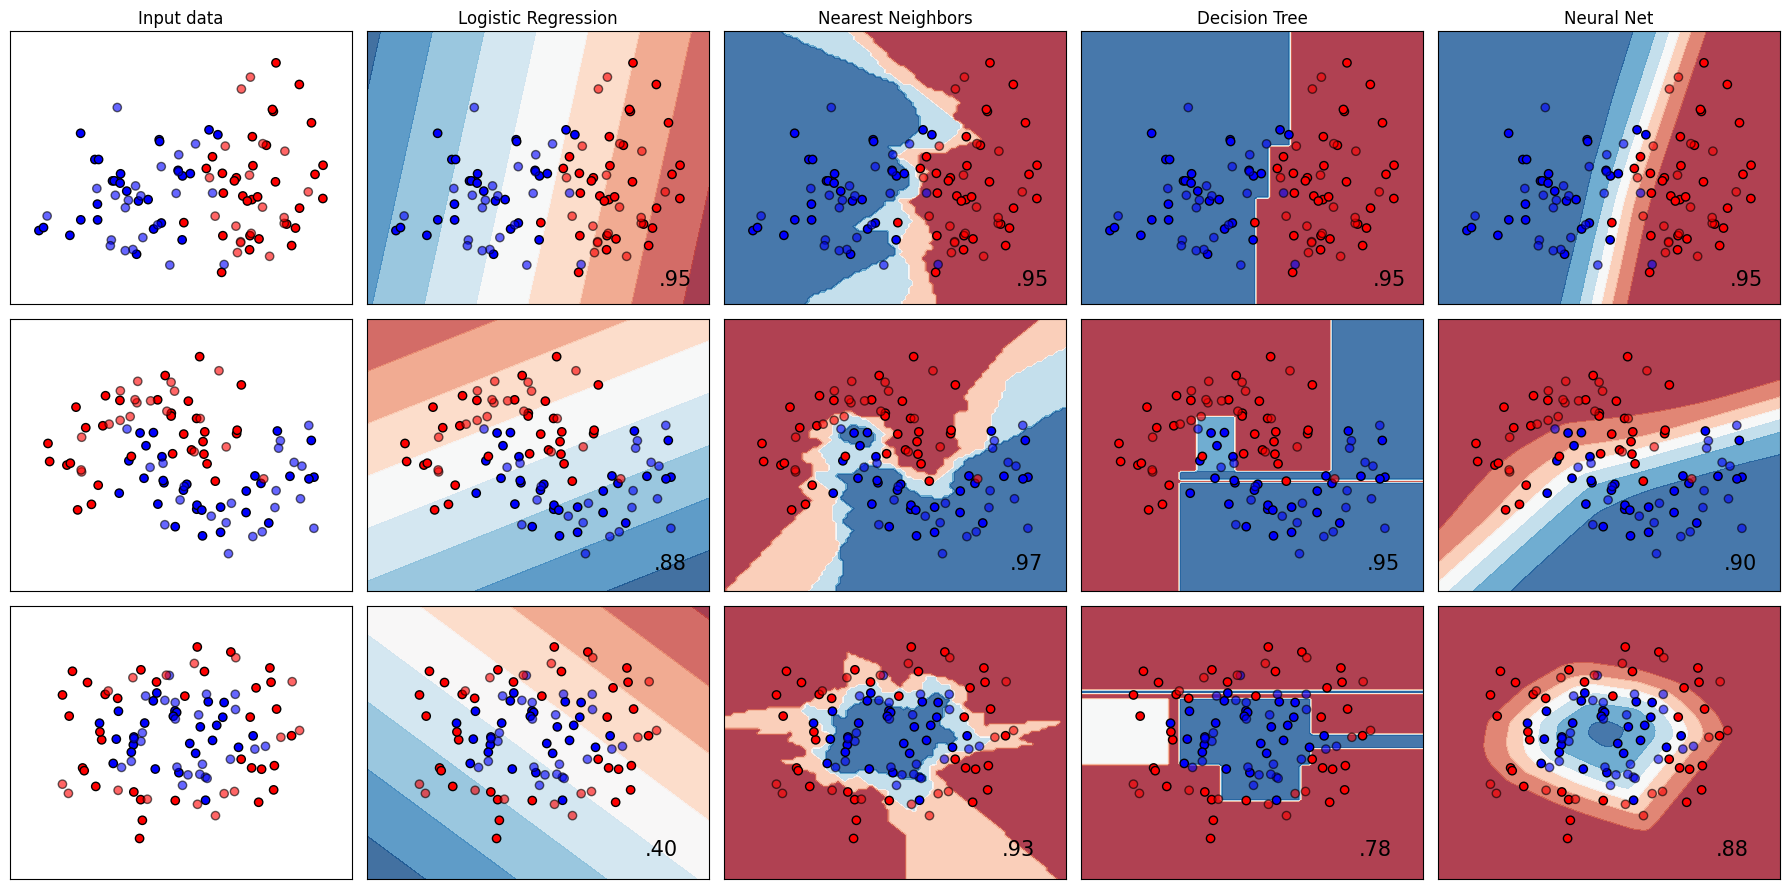

In [7]:
figure = plt.figure(figsize=(4.5*len(classifiers), 3*len(datasets)))
i = 1

# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()

Feel free to experiment by adding other datasets and models. The reference for each of the models can be found in the Scikit-learn documentation.

https://scikit-learn.org/stable/index.html